In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
from gurobipy import GRB
import glob
import pickle
import numpy as np

# Model Information

In [3]:
from networkx.utils import graphs_equal
def assert_equivalence(path):
    models = {}
    for model in glob.glob(f'{path}*.pickle'):
        model_name = model.split('model_')[1].split('_')[0]
        if model_name not in models:
            models[model_name] = [model]
        else:
            models[model_name].append(model)
    for k in models:
        if 'bpic' not in k and 'greps' not in k:
            continue
        m_base = None
        with open(models[k][0], 'rb') as handle:
            m_base = pickle.load(handle)
        for m in models[k][1:]:
            m_current = None
            with open(m, 'rb') as handle:
                m_current = pickle.load(handle)
            assert graphs_equal(m_current,m_base), f'{models[k][0]}, {m}, m_current.nodes()'
        print("Is equal", k)
assert_equivalence('out/models/')

Is equal bpic17-before
Is equal greps
Is equal bpic17-after
Is equal bpic17-both
Is equal bpic12


In [4]:
def transform_model_name(s):
    if 'greps' in s:
        return 'Greps'
    if 'bpic12' in s:
        return "BPIC12"
    if 'bpic17-before' in s:
        return "BPIC17-1"
    if 'bpic17-after' in s:
        return "BPIC17-2"
    if 'bpic17-both' in s:
        return "BPIC17"
    if 'spotify' in s:
        if s[-3] != "0":
            return f'MSSD{s[-3]}'
        if s[-4:-2] == "00":
            return 'MSSD100'
        return f'MSSD{s[-4:-2]}'
    if 'epidemic' in s:
        return s.capitalize()
    assert False, s

In [5]:
def model_information(path):
    print()
    info_dict = {'states' : {}, 'transitions' : {}, 'max_degree' : {}}
    for model in glob.glob(f'{path}*.pickle'):
        model_name = model.split('model_')[1].split('_')[0]
        model_name = transform_model_name(model_name)
        with open(model, 'rb') as handle:
            model = pickle.load(handle)
        if model_name not in info_dict['states']:
            info_dict['transitions'][model_name] = []
            info_dict['states'][model_name] = []
            info_dict['max_degree'][model_name] = []
        info_dict['states'][model_name].append(len(model.nodes()))
        info_dict['transitions'][model_name].append(len(model.edges()))
        degree_sequence = sorted((d for n, d in model.degree()), reverse=True)
        dmax = max(degree_sequence)
        info_dict['max_degree'][model_name].append(dmax)
    for k in info_dict:
        for k_inner in info_dict[k]:
            info_dict[k][k_inner] = sum(info_dict[k][k_inner])/len(info_dict[k][k_inner])
    print(info_dict)
    df = pd.DataFrame(data = info_dict)
    print(df)
    # df = pd.DataFrame(data={'States' : info_dict['states'], 'Transitions' : info_dict['transitions']}, index = info_dict['states'].keys())
    df.rename(columns = {'states' : 'States', 'transitions' : 'Transitions'}, inplace=True)
    
    s = ['Greps', "BPIC12", "BPIC17-1", "BPIC17-2", "BPIC17"]
    s.extend([f'MSSD{i*10}' for i in range(1,11)])
    s.extend([f'Epidemic{i}' for i in range(4, 20)])
    print(s)
    df = df.reindex(s)
    
    print(df.to_latex(index=True,
                formatters={"name": str.upper},
                float_format="{:.1f}".format, bold_rows = True,
    ))
    
    return df
model_information('out/models/')


{'states': {'BPIC17-1': 123.0, 'Greps': 64.0, 'MSSD30': 9474.2, 'MSSD40': 10637.6, 'MSSD90': 14361.2, 'MSSDy': 278.0, 'MSSD1': 1551.4, 'Epidemic16': 9539.0, 'MSSD60': 12480.2, 'Epidemic11': 3314.0, 'Epidemic9': 1902.0, 'MSSD10': 5828.4, 'MSSD5': 4027.0, 'MSSD80': 13785.8, 'MSSD100': 14860.0, 'Epidemic18': 13359.0, 'BPIC17-2': 142.0, 'BPIC17': 158.0, 'MSSD3': 3083.0, 'MSSD70': 13155.0, 'MSSD2': 2374.8, 'MSSD20': 7888.8, 'MSSD50': 11693.4, 'BPIC12': 129.0, 'Epidemic7': 962.0, 'Epidemic13': 5294.0, 'Epidemic8': 1379.0, 'Epidemic17': 11342.0, 'Epidemic19': 15602.0, 'Epidemic12': 4227.0, 'Epidemic5': 398.0, 'Epidemic6': 639.0, 'Epidemic15': 7938.0, 'Epidemic4': 227.0, 'Epidemic14': 6527.0, 'Epidemic10': 2543.0}, 'transitions': {'BPIC17-1': 211.0, 'Greps': 76.0, 'MSSD30': 19879.8, 'MSSD40': 22610.4, 'MSSD90': 31949.5, 'MSSDy': 438.0, 'MSSD1': 2745.5, 'Epidemic16': 110678.0, 'MSSD60': 27134.2, 'Epidemic11': 27913.0, 'Epidemic9': 13599.0, 'MSSD10': 11555.2, 'MSSD5': 7777.3, 'MSSD80': 30515.8,

,States,Transitions,max_degree
Greps,64.0,76.0,6.0
BPIC12,129.0,288.0,28.0
BPIC17-1,123.0,211.0,13.0
BPIC17-2,142.0,243.0,17.0
BPIC17,158.0,292.0,19.0
MSSD10,5828.4,11555.2,1979.5
MSSD20,7888.8,16201.5,2794.7
MSSD30,9474.2,19879.8,3410.0
MSSD40,10637.6,22610.4,3881.9
MSSD50,11693.4,25151.4,4297.9


# Greps and BPIC runtimes

In [6]:
df = pd.read_csv('out/results_greps_bpic.csv')
df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
df['model_name'] = df['model_name'].apply(transform_model_name)
df = df[df['model_name'] == "BPIC17"]
df = df[df['encoding'] == 'LP']
# df = df[df['importance_value'] == 1]

df_lower = df[df['sense'] == GRB.MINIMIZE]
df_upper = df[df['sense'] == GRB.MAXIMIZE]
df_grouped = pd.merge(df_lower, df_upper, left_on=['name', 'via_state'], right_on=['name', 'via_state'], how='left').sort_values(by =['importance_value_x', 'importance_value_y'], ascending=[False, False])[['via_state', 'importance_value_x', 'importance_value_y']]
print(tabulate(df_grouped.round(2), headers='keys', tablefmt='psql'))
print(df_grouped.to_latex(index=True,
            formatters={"name": str.upper},
            float_format="{:.2f}".format,
            bold_rows = True,
            multirow=True,
            multicolumn=True,
            multicolumn_format='c'
))

+-----+----------------------------------------------+----------------------+----------------------+
|     | via_state                                    |   importance_value_x |   importance_value_y |
|-----+----------------------------------------------+----------------------+----------------------|
|  18 | q0: start                                    |                 1    |                 1    |
|  24 | q2: A_CreateApplication                      |                 1    |                 1    |
|  52 | q105: O_Accepted                             |                 1    |                 1    |
|  89 | q131: A_Pending                              |                 1    |                 1    |
|  90 | q119: companyO_Accepted                      |                 1    |                 1    |
|  92 | q146: positive                               |                 1    |                 1    |
|  95 | q1: companystart                             |                 1    |              

In [7]:
def plot_results_df(path):
    df = pd.read_csv(path)
    # df = df[df['id'] == 0]
    
    df['status'] = df['status'].astype('category')
    df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
    df['model_name'] = df['model_name'].apply(transform_model_name)
    
    
    # df['target_prob_quantile'] = pd.qcut(df['target_prob'], 10, labels=False)
    df_grouped = df.groupby(['model_name', 'encoding'])['time'].agg(['mean','std', 'min', 'max']).reset_index()
    
    df_grouped.rename(columns = {'mean' : 'mean(t)', 'std' : 'std(t)', 'min' : 'min(t)', 'max' : 'max(t)', 'model_name' : 'Model'}, inplace=True)
    
    df_grouped_not_agg = df.groupby(['model_name', 'encoding', 'status']).size()
    recorded_status = df['status'].values
        
    print(df_grouped)
    df_grouped['Opt.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.OPTIMAL].values if GRB.OPTIMAL in recorded_status else 0
    # df_grouped['Inf.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.INFEASIBLE].values if GRB.INFEASIBLE in recorded_status else 0
    df_grouped['T.O.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.TIME_LIMIT].values if GRB.TIME_LIMIT in recorded_status else 0 
    df_grouped['M.O.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.MEM_LIMIT].values if GRB.MEM_LIMIT in recorded_status else 0
    
    df_grouped['T.O.'].astype(object) 
    
    df_grouped.set_index(["Model", 'encoding'], inplace=True)
    df_grouped.sort_index(ascending=[False, False], inplace=True)
    
    
    #df = df.groupby('model_name').mean().reset_index()    
    df_grouped = df_grouped.reindex([(m, e) for m in ['Greps', "BPIC12", "BPIC17"] for e in ['GQP', 'QP', 'LP']])
    print(tabulate(df_grouped.round(2), headers='keys', tablefmt='psql'))
    
    # df_grouped['max(t)'] = df_grouped['max(t)'].apply(np.round)
    # df_grouped.loc[df_grouped['max(t)'] >= df['timeout'].values[0], 'max(t)'] = 'T.O.'
    
    df_grouped = df_grouped.applymap(lambda x: round(x, 2) if isinstance(x, (int, float)) else x)
    
    print(df_grouped.to_latex(index=True,
                formatters={"name": str.upper},
                float_format="{:.2f}".format,
                bold_rows = True,
                multirow=True,
                multicolumn=True,
                multicolumn_format='c'
    ))

plot_results_df('out/results_greps_bpic.csv')

    Model encoding      mean(t)       std(t)    min(t)       max(t)
0  BPIC12      GQP  1616.912983  1419.136251  0.020228  3600.029410
1  BPIC12       LP     0.022246     0.017071  0.004896     0.107230
2  BPIC12       QP     2.953273    11.947385  0.005945   102.304719
3  BPIC17      GQP    23.275915   209.618968  0.032751  3600.001317
4  BPIC17       LP     0.068989     0.052766  0.006575     0.765963
5  BPIC17       QP     2.663715     5.254577  0.024325    37.493179
6   Greps      GQP     0.057164     0.062964  0.004070     0.636613
7   Greps       LP     0.033767     0.028602  0.002641     0.192158
8   Greps       QP     0.168026     0.129451  0.004250     0.730760
+-------------------+-----------+----------+----------+----------+--------+--------+--------+
|                   |   mean(t) |   std(t) |   min(t) |   max(t) |   Opt. |   T.O. |   M.O. |
|-------------------+-----------+----------+----------+----------+--------+--------+--------|
| ('Greps', 'GQP')  |      0.06 |     

/tmp/ipykernel_21838/3256820113.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_not_agg = df.groupby(['model_name', 'encoding', 'status']).size()
/tmp/ipykernel_21838/3256820113.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_grouped = df_grouped.applymap(lambda x: round(x, 2) if isinstance(x, (int, float)) else x)


In [8]:
def plot_results_df_lower_upper(path):
    df = pd.read_csv(path)
    # df = df[df['id'] == 0]
    # df = df[df['sense'] == sense]
    
    df['sense'] = df['sense'].replace(GRB.MINIMIZE, 'min')
    df['sense'] = df['sense'].replace(GRB.MAXIMIZE, 'max')
    df['status'] = df['status'].astype('category')
    df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
    df['model_name'] = df['model_name'].apply(transform_model_name)
    
    
    # df['target_prob_quantile'] = pd.qcut(df['target_prob'], 10, labels=False)
    df_grouped = df.groupby(['model_name', 'encoding', 'sense'])['time'].agg(['mean','std', 'min', 'max']).reset_index()
    
    df_grouped.rename(columns = {'mean' : 'mean(t)', 'std' : 'std(t)', 'min' : 'min(t)', 'max' : 'max(t)', 'model_name' : 'Model'}, inplace=True)
    
    df_grouped_not_agg = df.groupby(['model_name', 'encoding', 'sense', 'status']).size()
    recorded_status = df['status'].values
        
    print(df_grouped)
    df_grouped['Opt.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, :, GRB.OPTIMAL].values if GRB.OPTIMAL in recorded_status else 0
    # df_grouped['Inf.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.INFEASIBLE].values if GRB.INFEASIBLE in recorded_status else 0
    df_grouped['T.O.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, :, GRB.TIME_LIMIT].values if GRB.TIME_LIMIT in recorded_status else 0 
    df_grouped['M.O.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, :, GRB.MEM_LIMIT].values if GRB.MEM_LIMIT in recorded_status else 0
    
    df_grouped['T.O.'].astype(object) 
    
    # df_grouped['max(t)'] = df_grouped['max(t)'].round(2)
    # df_grouped.loc[df_grouped['max(t)'] >= df['timeout'].values[0], 'max(t)'] = 'T.O.'
    
    df_grouped.set_index(["Model", 'encoding', 'sense'], inplace=True)
    df_grouped.sort_index(ascending=[False, True, False], inplace=True)
    
    #df = df.groupby('model_name').mean().reset_index()    
    df_grouped = df_grouped.reindex([(m, e, s) for m in ['Greps', "BPIC12", "BPIC17"] for e in ['GQP', 'QP', 'LP'] for s in ['min', 'max']])
    print(tabulate(df_grouped.round(2), headers='keys', tablefmt='psql'))
    # df_grouped = df_grouped.reindex(['Greps', "BPIC'12", "BPIC'17"])
        
    print(df_grouped.to_latex(index=True,
                formatters={"name": str.upper},
                float_format="{:.2f}".format,
                bold_rows = True,
                multirow=True,
                multicolumn=True,
                multicolumn_format='c',
    ))

plot_results_df_lower_upper('out/results_greps_bpic.csv')

/tmp/ipykernel_21838/2633230332.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_not_agg = df.groupby(['model_name', 'encoding', 'sense', 'status']).size()


     Model encoding sense      mean(t)       std(t)    min(t)       max(t)
0   BPIC12      GQP   max  2303.719932  1386.693182  0.020243  3600.005386
1   BPIC12      GQP   min   930.106035  1081.634615  0.020228  3600.029410
2   BPIC12       LP   max     0.017020     0.003929  0.004896     0.027781
3   BPIC12       LP   min     0.027473     0.022685  0.005763     0.107230
4   BPIC12       QP   max     0.392391     0.965444  0.006088     9.705373
5   BPIC12       QP   min     5.514156    16.505890  0.005945   102.304719
6   BPIC17      GQP   max    41.392781   295.540625  0.033602  3600.001317
7   BPIC17      GQP   min     5.159048    12.458439  0.032751    65.047180
8   BPIC17       LP   max     0.079738     0.061430  0.006593     0.765963
9   BPIC17       LP   min     0.058240     0.039751  0.006575     0.194636
10  BPIC17       QP   max     2.991495     5.481971  0.026276    36.489658
11  BPIC17       QP   min     2.335934     5.012861  0.024325    37.493179
12   Greps      GQP   max

In [9]:
def differences(path):
    df = pd.read_csv(path)
    df['sense'] = df['sense'].replace(GRB.MINIMIZE, 'min')
    df['sense'] = df['sense'].replace(GRB.MAXIMIZE, 'max')
    
    df['status'] = df['status'].astype('category')
    df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
    df['model_name'] = df['model_name'].apply(transform_model_name)
        
    df_lp = df[df['encoding']=='LP']
    df_qp = df[df['encoding']=='QP']

    df_lp = df_lp.set_index(['model_name', 'via_state', 'sense'])
    df_qp = df_qp.set_index(['model_name', 'via_state', 'sense'])
    
    df_diff = (abs(df_lp['importance_value']-df_qp['importance_value'])).to_frame()
    
    df_grouped = df_diff.groupby(['model_name', 'sense'])['importance_value'].agg(['mean','std', 'min', 'max'])
    df_grouped = df_grouped.reindex([(m, s) for m in ['Greps', "BPIC12", "BPIC17"] for s in ['min', 'max']])
    # df_grouped = df_grouped.reindex(['Greps', "BPIC12", "BPIC17"])
    print(df_grouped)
    print(df_grouped.to_latex(index=True,
                formatters={"name": str.upper},
                float_format="{:.2e}".format,
                bold_rows = True,
                multirow=True,
                multicolumn=True,
                multicolumn_format='c'
    ).replace('0.00e+00', '0'))
    
differences('out/results_greps_bpic.csv')

                          mean           std  min           max
model_name sense                                               
Greps      min    1.156844e-16  2.943873e-16  0.0  1.332268e-15
           max    1.104802e-16  3.045502e-16  0.0  1.665335e-15
BPIC12     min    0.000000e+00  0.000000e+00  0.0  0.000000e+00
           max    4.271972e-08  4.852028e-07  0.0  5.510844e-06
BPIC17     min    3.883222e-04  2.812818e-03  0.0  3.327086e-02
           max    7.781655e-05  3.320390e-04  0.0  3.692346e-03
\begin{tabular}{llrrrr}
\toprule
 &  & mean & std & min & max \\
model_name & sense &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{\textbf{Greps}} & \textbf{min} & 1.16e-16 & 2.94e-16 & 0 & 1.33e-15 \\
\textbf{} & \textbf{max} & 1.10e-16 & 3.05e-16 & 0 & 1.67e-15 \\
\cline{1-6}
\multirow[t]{2}{*}{\textbf{BPIC12}} & \textbf{min} & 0 & 0 & 0 & 0 \\
\textbf{} & \textbf{max} & 4.27e-08 & 4.85e-07 & 0 & 5.51e-06 \\
\cline{1-6}
\multirow[t]{2}{*}{\textbf{BPIC17}} & \textbf{min} & 3.88e-04 & 2.

# Epidemic

In [10]:
def plot_results_df(path):
    df = pd.read_csv(path)
    # df = df[df['id'] == 0]
    
    df['status'] = df['status'].astype('category')
    df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
    df['model_name'] = df['model_name'].apply(transform_model_name)
    
    
    # df['target_prob_quantile'] = pd.qcut(df['target_prob'], 10, labels=False)
    df_grouped = df.groupby(['model_name', 'encoding'])['time'].agg(['mean','std', 'min', 'max']).reset_index()
    
    df_grouped.rename(columns = {'mean' : 'mean(t)', 'std' : 'std(t)', 'min' : 'min(t)', 'max' : 'max(t)', 'model_name' : 'Model'}, inplace=True)
    
    df_grouped_not_agg = df.groupby(['model_name', 'encoding', 'status']).size()
    recorded_status = df['status'].values
        
    print(df_grouped)
    df_grouped['Opt.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.OPTIMAL].values if GRB.OPTIMAL in recorded_status else 0
    # df_grouped['Inf.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.INFEASIBLE].values if GRB.INFEASIBLE in recorded_status else 0
    df_grouped['T.O.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.TIME_LIMIT].values if GRB.TIME_LIMIT in recorded_status else 0 
    df_grouped['M.O.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.MEM_LIMIT].values if GRB.MEM_LIMIT in recorded_status else 0
    
    df_grouped['T.O.'].astype(object) 
    
    # df_grouped['max(t)'] = df_grouped['max(t)'].round(2)
    # df_grouped.loc[df_grouped['max(t)'] >= df['timeout'].values[0], 'max(t)'] = 'T.O.'
    
    df_grouped.set_index(["Model", 'encoding'], inplace=True)
    df_grouped.sort_index(ascending=[False, False], inplace=True)
    
    #df = df.groupby('model_name').mean().reset_index()    
    df_grouped = df_grouped.reindex([(m, e) for m in [f'Epidemic{i}' for i in range(4,20)] for e in ['QP', 'LP']])
    print(tabulate(df_grouped.round(2), headers='keys', tablefmt='psql'))
        
    print(df_grouped.to_latex(index=True,
                formatters={"name": str.upper},
                float_format="{:.2f}".format,
                bold_rows = True,
                multirow=True,
                multicolumn=True,
                multicolumn_format='c'
    ))
    
plot_results_df('out/results_epidemic.csv')

         Model encoding      mean(t)       std(t)    min(t)       max(t)
0   Epidemic10       LP     0.011781     0.004806  0.005212     0.019748
1   Epidemic10       QP  1399.824283  1751.826733  0.023849  3600.050771
2   Epidemic11       LP     0.013091     0.006023  0.005801     0.024062
3   Epidemic11       QP  1654.711727  1804.197985  0.032263  3600.078877
4   Epidemic12       LP     0.016573     0.008358  0.006557     0.031975
5   Epidemic12       QP  1728.057303  1816.832339  0.040787  3600.204661
6   Epidemic13       LP     0.021727     0.011538  0.007926     0.043540
7   Epidemic13       QP  1733.399384  1815.660854  0.051366  3600.138283
8   Epidemic14       LP     0.027302     0.015865  0.009197     0.057606
9   Epidemic14       QP  1738.008223  1814.645351  0.062501  3600.142840
10  Epidemic15       LP     0.044600     0.023630  0.010467     0.080850
11  Epidemic15       QP  1742.015453  1813.739213  0.079639  3600.129249
12  Epidemic16       LP     0.059478     0.025983  

/tmp/ipykernel_21838/2157740696.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_not_agg = df.groupby(['model_name', 'encoding', 'status']).size()


In [11]:
def plot_results_df_lower_upper(path):
    df = pd.read_csv(path)
    # df = df[df['id'] == 0]
    # df = df[df['sense'] == sense]
    
    df['sense'] = df['sense'].replace(GRB.MINIMIZE, 'min')
    df['sense'] = df['sense'].replace(GRB.MAXIMIZE, 'max')
    df['status'] = df['status'].astype('category')
    df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
    df['model_name'] = df['model_name'].apply(transform_model_name)
    
    
    # df['target_prob_quantile'] = pd.qcut(df['target_prob'], 10, labels=False)
    df_grouped = df.groupby(['model_name', 'encoding', 'sense'])['time'].agg(['mean','std', 'min', 'max']).reset_index()
    
    df_grouped.rename(columns = {'mean' : 'mean(t)', 'std' : 'std(t)', 'min' : 'min(t)', 'max' : 'max(t)', 'model_name' : 'Model'}, inplace=True)
    
    df_grouped_not_agg = df.groupby(['model_name', 'encoding', 'sense', 'status']).size()
    recorded_status = df['status'].values
        
    print(df_grouped)
    df_grouped['Opt.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, :, GRB.OPTIMAL].values if GRB.OPTIMAL in recorded_status else 0
    # df_grouped['Inf.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.INFEASIBLE].values if GRB.INFEASIBLE in recorded_status else 0
    df_grouped['T.O.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, :, GRB.TIME_LIMIT].values if GRB.TIME_LIMIT in recorded_status else 0 
    df_grouped['M.O.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, :, GRB.MEM_LIMIT].values if GRB.MEM_LIMIT in recorded_status else 0
    
    df_grouped['T.O.'].astype(object) 
    
    # df_grouped['max(t)'] = df_grouped['max(t)'].round(2)
    # df_grouped.loc[df_grouped['max(t)'] >= df['timeout'].values[0], 'max(t)'] = 'T.O.'
    
    df_grouped.set_index(["Model", 'encoding', 'sense'], inplace=True)
    df_grouped.sort_index(ascending=[False, True, False], inplace=True)
    
    #df = df.groupby('model_name').mean().reset_index()    
    df_grouped = df_grouped.reindex([(m, e, s) for m in [f'Epidemic{i}' for i in range(4,20)] for e in ['QP', 'LP'] for s in ['min', 'max']])
    print(tabulate(df_grouped.round(2), headers='keys', tablefmt='psql'))
    # df_grouped = df_grouped.reindex(['Greps', "BPIC'12", "BPIC'17"])
        
    print(df_grouped.to_latex(index=True,
                formatters={"name": str.upper},
                float_format="{:.2f}".format,
                bold_rows = True,
                multirow=True,
                multicolumn=True,
                multicolumn_format='c',
    ).replace('\multirow[t]', '\multirow[c]'))
plot_results_df_lower_upper('out/results_epidemic.csv')

<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_21838/3511315042.py:47: SyntaxWarning: invalid escape sequence '\m'
  ).replace('\multirow[t]', '\multirow[c]'))
/tmp/ipykernel_21838/3511315042.py:47: SyntaxWarning: invalid escape sequence '\m'
  ).replace('\multirow[t]', '\multirow[c]'))
/tmp/ipykernel_21838/3511315042.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_not_agg = df.groupby(['model_name', 'encoding', 'sense', 'status']).size()


         Model encoding sense      mean(t)       std(t)    min(t)       max(t)
0   Epidemic10       LP   max     0.014220     0.002636  0.011535     0.019748
1   Epidemic10       LP   min     0.009343     0.005283  0.005212     0.018872
2   Epidemic10       QP   max  1380.957937  1784.160663  0.023858  3600.036524
3   Epidemic10       QP   min  1418.690630  1762.742723  0.023849  3600.050771
4   Epidemic11       LP   max     0.012281     0.004831  0.006942     0.023776
..         ...      ...   ...          ...          ...       ...          ...
59   Epidemic8       QP   min   437.433084  1190.538599  0.015436  3600.024050
60   Epidemic9       LP   max     0.010359     0.001962  0.004898     0.014837
61   Epidemic9       LP   min     0.007636     0.003378  0.004404     0.013041
62   Epidemic9       QP   max   777.693043  1497.806601  0.017908  3600.042938
63   Epidemic9       QP   min   597.521521  1336.782687  0.017458  3600.030303

[64 rows x 7 columns]
+----------------------------

In [12]:
df = pd.read_csv('out/results_epidemic.csv')
df = df[(df['name'].str.contains('epidemic8'))]# & (df['sense'] == GRB.MINIMIZE)]
df[df['time']>3600]['via_state']

394    (8, 1, 14)
396    (8, 1, 15)
398     (8, 1, 9)
400    (8, 1, 13)
402    (8, 1, 15)
404    (8, 1, 16)
Name: via_state, dtype: object

In [13]:
df = pd.read_csv('out/results_epidemic.csv')
df = df[(df['name'].str.contains('epidemic9'))]# & (df['sense'] == GRB.MINIMIZE)]
df[df['time']>3600]['via_state']

406    (9, 1, 14)
408    (9, 1, 11)
410    (9, 1, 16)
412    (9, 1, 15)
414    (9, 1, 17)
416    (9, 1, 13)
422    (9, 1, 14)
Name: via_state, dtype: object

In [14]:
df = pd.read_csv('out/results_epidemic.csv')
df = df[(df['name'].str.contains('epidemic10'))]# & (df['sense'] == GRB.MINIMIZE)]
df[df['time']>3600]['via_state']

424    (10, 1, 15)
432    (10, 1, 16)
434    (10, 1, 13)
440    (10, 1, 12)
446    (10, 1, 11)
448    (10, 1, 14)
460    (10, 1, 18)
464    (10, 1, 20)
468    (10, 1, 18)
472    (10, 1, 16)
474    (10, 1, 19)
478    (10, 1, 11)
480    (10, 1, 20)
482    (10, 1, 14)
488    (10, 1, 13)
492    (10, 1, 12)
Name: via_state, dtype: object

In [15]:
df = pd.read_csv('out/results_epidemic.csv')
df = df[df['encoding']=='LP']
df = df[df['sense']==GRB.MAXIMIZE]
# df['importance_value'] == 
# max(df['via_state'].apply(lambda x: int(x.replace("(", "").replace(")", "").split(",")[0])) + 1 - df['via_state'].apply(lambda x: int(x.replace("(", "").replace(")", "").split(",")[2])), 1)

for index, row in df.iterrows():
    if row['importance_value'] == 1:
        assert int(row['via_state'].replace("(", "").replace(")", "").split(",")[0]) + 1 <= int(row['via_state'].replace("(", "").replace(")", "").split(",")[2]), row
    else:
        assert int(row['via_state'].replace("(", "").replace(")", "").split(",")[0]) + 1 > int(row['via_state'].replace("(", "").replace(")", "").split(",")[2]), row
        
    if row['time']>3600:
        assert int(row['via_state'].replace("(", "").replace(")", "").split(",")[0]) < int(row['via_state'].replace("(", "").replace(")", "").split(",")[2]), row
    # print(max(int(row['via_state'].replace("(", "").replace(")", "").split(",")[0]) + 1 - int(row['via_state'].replace("(", "").replace(")", "").split(",")[2]), 1))
    
df = pd.read_csv('out/results_epidemic.csv')
df = df[df['encoding']=='LP']
df = df[df['sense']==GRB.MINIMIZE]
assert (df['importance_value']==0).all()
for index, row in df.iterrows():
    assert row['importance_value'] == 0

# Spotify

In [16]:
def plot_results_df(path):
    df = pd.read_csv(path)
    # df = df[df['id'] == 0]
    
    df['status'] = df['status'].astype('category')
    print(df['name'])
    df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
    df['model_name'] = df['model_name'].apply(transform_model_name)
    print(df['model_name'])
    
    # df['target_prob_quantile'] = pd.qcut(df['target_prob'], 10, labels=False)
    df_grouped = df.groupby(['model_name', 'encoding'])['time'].agg(['mean','std', 'min', 'max']).reset_index()
    
    df_grouped.rename(columns = {'mean' : 'mean(t)', 'std' : 'std(t)', 'min' : 'min(t)', 'max' : 'max(t)', 'model_name' : 'Model'}, inplace=True)
    
    df_grouped_not_agg = df.groupby(['model_name', 'encoding', 'status']).size()
    recorded_status = df['status'].values
        
    print(df_grouped)
    df_grouped['Opt.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.OPTIMAL].values if GRB.OPTIMAL in recorded_status else 0
    # df_grouped['Inf.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.INFEASIBLE].values if GRB.INFEASIBLE in recorded_status else 0
    df_grouped['T.O.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.TIME_LIMIT].values if GRB.TIME_LIMIT in recorded_status else 0 
    df_grouped['M.O.'] = df_grouped_not_agg.loc[df_grouped['Model'].values, :, GRB.MEM_LIMIT].values if GRB.MEM_LIMIT in recorded_status else 0
    
    df_grouped['T.O.'].astype(object) 
    df_grouped.loc[df_grouped['max(t)'] >= df['timeout'].values[0], 'max(t)'] = 'T.O.'
    
    df_grouped.set_index(["Model", 'encoding'], inplace=True)
    df_grouped.sort_index(ascending=[True, False], inplace=True)
    
    #df = df.groupby('model_name').mean().reset_index()    
    # df_grouped = df_grouped.reindex([(m, e) for m in ['Greps', "BPIC12", "BPIC17"] for e in ['GQP', 'QP', 'LP']])
    df_grouped = df_grouped.reindex([(m, e) for m in [f'MSSD{(10*i)}' for i in range(1,11)] for e in ['LP'] ])
    
    print(tabulate(df_grouped.round(2), headers='keys', tablefmt='psql'))
        
    print(df_grouped.to_latex(index=True,
                formatters={"name": str.upper},
                float_format="{:.2f}".format,
                bold_rows = True,
                multirow=True,
                multicolumn=True,
                multicolumn_format='c'
    ))

plot_results_df('out/results_spotify_songs.csv')

0       out/models/model_spotify1000_model-it_0.pickle
1       out/models/model_spotify1000_model-it_0.pickle
2       out/models/model_spotify1000_model-it_2.pickle
3       out/models/model_spotify1000_model-it_2.pickle
4       out/models/model_spotify1000_model-it_3.pickle
                            ...                       
995    out/models/model_spotify10000_model-it_7.pickle
996    out/models/model_spotify10000_model-it_9.pickle
997    out/models/model_spotify10000_model-it_8.pickle
998    out/models/model_spotify10000_model-it_9.pickle
999    out/models/model_spotify10000_model-it_9.pickle
Name: name, Length: 1000, dtype: object
0       MSSD10
1       MSSD10
2       MSSD10
3       MSSD10
4       MSSD10
        ...   
995    MSSD100
996    MSSD100
997    MSSD100
998    MSSD100
999    MSSD100
Name: model_name, Length: 1000, dtype: object
     Model encoding      mean(t)       std(t)     min(t)       max(t)
0   MSSD10       LP   423.652409   924.645928   1.560049  3600.001785
1  M

/tmp/ipykernel_21838/3640753634.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_not_agg = df.groupby(['model_name', 'encoding', 'status']).size()
/tmp/ipykernel_21838/3640753634.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'T.O.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_grouped.loc[df_grouped['max(t)'] >= df['timeout'].values[0], 'max(t)'] = 'T.O.'


model_name  via_state_type     
MSSD10      companyplayed          21
            companysong            18
            companystartprofile     5
            customerselect          1
            played                 34
            song                   20
            startprofile            1
MSSD100     companyplayed          31
            companysong            17
            played                 22
            song                   26
            startprofile            4
MSSD20      companyplayed          35
            companysong            14
            companystartprofile     1
            played                 31
            song                   17
            startprofile            2
MSSD30      companyplayed          29
            companysong            16
            companystartprofile     3
            played                 35
            song                   15
            startprofile            2
dtype: int64


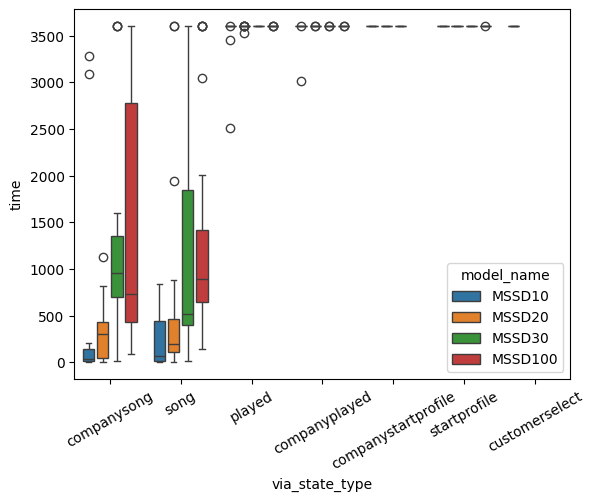

In [17]:
df = pd.read_csv('out/results_spotify.csv')
df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
df['model_name'] = df['model_name'].apply(transform_model_name)
df = df[df['model_name'].str.contains('|'.join([f'MSSD{10*i}' for i in range(1,4)]))]
df['via_state_type'] = df['via_state'].str.split(': ').str[1].str.split('_').str[0]
print(df.groupby(['model_name', 'via_state_type']).size())
plt.xticks(rotation=30)
plot = sns.boxplot(data=df, y='time', x='via_state_type', hue="model_name", fill=True, gap=.2)

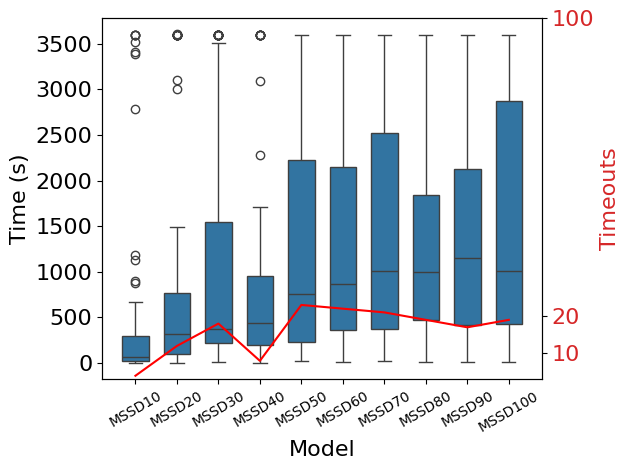

In [18]:
labels = [f'MSSD{10*i}' for i in range(1, 11)]
df = pd.read_csv('out/results_spotify_songs.csv')
df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
df['model_name'] = df['model_name'].apply(transform_model_name)
# df = df[df['model_name'].str.contains('|'.join([f'MSSD{10*i}' for i in range(1,4)]))]
df['via_state_type'] = df['via_state'].str.split(': ').str[1].str.split('_').str[0]
df = df[df['via_state_type'].str.contains('song')]

df_counts = df[df['time']>3600].groupby(['model_name'])['model_name'].agg(['size']).reset_index()

my_list = [df[df['model_name']==l]['time'] for l in labels]
my_mean = [df_counts[df_counts['model_name']==l]['size'] for l in labels]

fig, ax1 = plt.subplots()

color = 'tab:red'
# ax1.boxplot(my_list, labels=labels)
sns.boxplot(data=df, y='time', x='model_name', fill=True, gap=.2, ax=ax1)
ax1.set_ylabel('Time (s)', fontsize=16)
ax1.set_xlabel('Model', fontsize=16)
plt.xticks(rotation=30)
plt.yticks(fontsize=16)

ax2 = ax1.twinx() 
ax2.plot(np.arange(len(my_mean)), my_mean, color='r')
ax2.set_ylabel('Timeouts', color=color, fontsize=16)
plt.yticks([10, 20, 100], color=color, fontsize=16)


fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig('out/mssd.png', dpi=600)
plt.show()

371             song
373      companysong
374             song
376      companysong
378      companysong
           ...      
903             song
905           played
906    companyplayed
907           played
908           played
Name: via_state_type, Length: 499, dtype: object


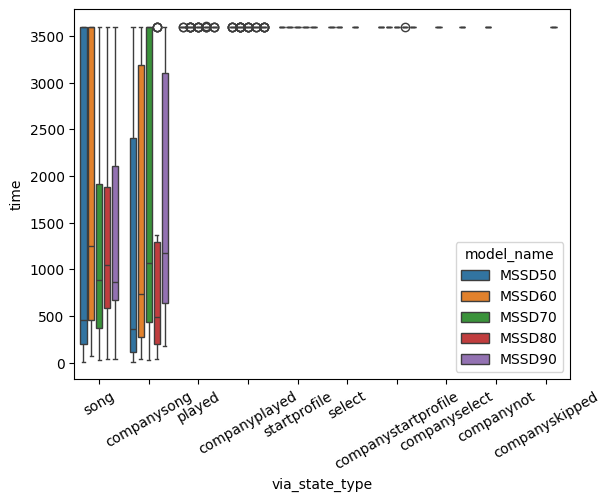

In [19]:
df = pd.read_csv('out/results_spotify.csv')
df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
df['model_name'] = df['model_name'].apply(transform_model_name)
df = df[df['model_name'].str.contains('|'.join([f'MSSD{10*i}' for i in range(5,10)]))]
df['via_state_type'] = df['via_state'].str.split(': ').str[1].str.split('_').str[0]
print(df['via_state_type'])
plt.xticks(rotation=30)
plot = sns.boxplot(data=df, y='time', x='via_state_type', hue="model_name", fill=True, gap=.2)

model_name
MSSD10     100
MSSD100    100
MSSD20     100
MSSD30     100
MSSD40     100
MSSD50     100
MSSD60     100
MSSD70     100
MSSD80     100
MSSD90     100
dtype: int64


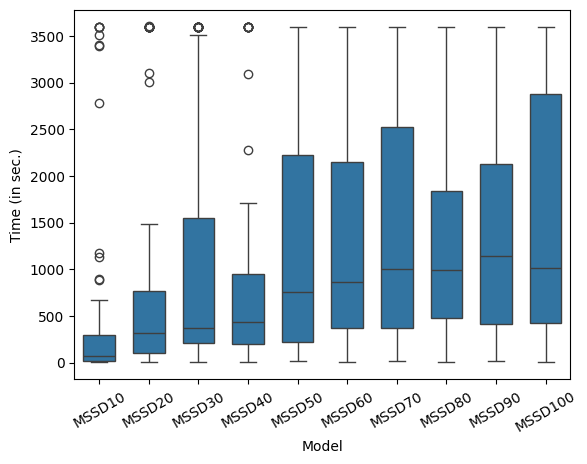

In [20]:
df = pd.read_csv('out/results_spotify_songs.csv')
df['model_name'] = df['name'].str.split('model_').str[1].str.split('_').str[0]
df['model_name'] = df['model_name'].apply(transform_model_name)
# df = df[df['model_name'].str.contains('|'.join([f'MSSD{10*i}' for i in range(1,4)]))]
# df['via_state_type'] = df['via_state'].str.split(': ').str[1].str.split('_').str[0]
# df = df[df['via_state_type'].str.contains('song')]
print(df.groupby(['model_name']).size())
plt.xticks(rotation=30)
plt.xlabel("Model")
plt.ylabel("Time (in sec.)")
plot = sns.boxplot(data=df, y='time', x='model_name', fill=True, gap=.2)
plt.savefig("out/mssd.png", dpi=300)

In [21]:
import networkx as nx
with open('out/models/model_spotify10_model-it_0.pickle', 'rb') as handle: #open(f'out/models/model_{name}.pickle', 'rb') as handle:
    mdp = pickle.load(handle)
A = nx.nx_agraph.to_agraph(mdp)
A.layout('dot')
A.draw(f'out/mssd_{10}.ps')
# from networkx.drawing.nx_pydot import write_dot
# write_dot(mdp, f'out/mssd_{10}.dot')